In [12]:
import random
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [13]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [14]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.367883,-2.271460,-4.113656,-2.277007,-0.061393,0
1,0.251788,-0.575842,0.658503,0.044930,-1.809686,0
2,0.305891,-0.407380,0.225240,0.624004,-0.160386,0
3,0.571299,3.356935,-0.384358,2.455698,1.056650,1
4,-1.793273,0.010594,-1.579584,-1.304074,0.620449,0


In [15]:
# Function for row sampling

def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]), replace=True)

In [32]:
df.shape

(100, 6)

In [34]:
df.shape[1]-1

5

In [16]:
# Function for feature sampling

def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [17]:
# Function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [18]:
df1 = combined_sampling(df,0.5,0.5)

In [19]:
df1

,col2,col5,target
94,3.662171,-1.784930,1
25,1.115987,0.634319,1
91,-2.737044,-0.684199,0
56,-0.708532,-2.411492,1
77,-2.469828,-1.170151,0
10,0.976054,-0.668549,0
74,0.523637,1.516147,0
41,3.290390,-1.312468,1
42,-0.852194,-0.255825,0
96,1.136455,0.237022,1


In [20]:
df2 = sample_rows(df,0.2)

In [21]:
df2

,col1,col2,col3,col4,col5,target
92,-0.698034,-0.990906,0.340046,-1.690539,-2.873251,0
89,-1.315493,-0.546620,-0.599719,-1.366624,-0.971407,0
36,1.878304,-0.772141,-0.279415,1.640668,0.218460,1
6,0.464986,1.421576,-0.478681,-0.761943,-1.612738,1
97,-3.722613,1.845919,-1.321989,-2.394462,0.143029,0
32,1.379719,1.518141,1.044965,3.389135,0.949235,1
76,-1.246120,-1.002563,-0.410766,-1.987906,-2.768880,0
83,-0.052694,0.639834,1.975116,1.107039,-1.168000,1
73,-2.515273,0.048089,-1.146940,-0.841573,-0.270895,0
20,-2.791363,0.959552,-0.940178,-2.547219,-0.956978,0


In [22]:
df.shape

(100, 6)

In [23]:
df1 = combined_sampling(df,0.5,0.5)

In [24]:
df2 = combined_sampling(df,0.5,0.5)

In [25]:
df3 = combined_sampling(df,0.5,0.5)

In [26]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col2', 'target'], dtype='str')
Index(['col4', 'col3', 'target'], dtype='str')
Index(['col1', 'col4', 'target'], dtype='str')


In [27]:
df3

,col1,col4,target
13,2.140035,3.386065,1
15,-2.202289,-1.707112,0
51,-0.260835,-0.882704,0
20,-2.791363,-2.547219,0
30,0.634590,-0.227365,0
95,1.495090,2.196576,1
40,-1.956330,-2.916848,0
22,-3.235546,-1.211146,0
70,1.657424,0.661638,1
42,-2.844873,-2.275996,0


In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [30]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [35]:
from sklearn.tree import plot_tree

[Text(0.6666666666666666, 0.9, 'x[0] <= 0.643\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.5, 0.7, 'x[1] <= 1.199\ngini = 0.36\nsamples = 34\nvalue = [26, 8]'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'x[1] <= 0.155\ngini = 0.185\nsamples = 29\nvalue = [26, 3]'),
 Text(0.16666666666666666, 0.3, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]'),
 Text(0.5, 0.3, 'x[1] <= 0.433\ngini = 0.444\nsamples = 9\nvalue = [6, 3]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.6666666666666666, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.8333333333333334, 0.7, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.75, 0.8, '  False')]

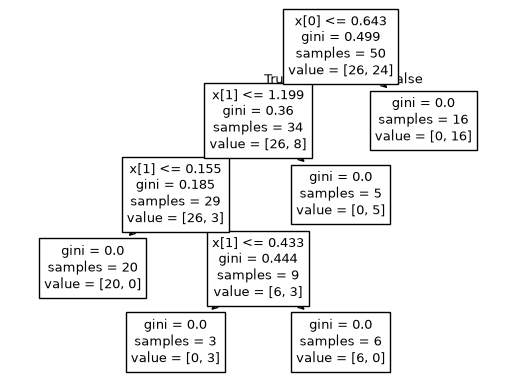

In [36]:
plot_tree(clf1)

[Text(0.5, 0.95, 'x[1] <= -0.547\ngini = 0.461\nsamples = 50\nvalue = [18, 32]'),
 Text(0.3, 0.85, 'x[1] <= -1.19\ngini = 0.133\nsamples = 14\nvalue = [13, 1]'),
 Text(0.4, 0.8999999999999999, 'True  '),
 Text(0.2, 0.75, 'x[1] <= -1.403\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.1, 0.65, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.3, 0.65, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.75, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.7, 0.85, 'x[0] <= -1.529\ngini = 0.239\nsamples = 36\nvalue = [5, 31]'),
 Text(0.6, 0.8999999999999999, '  False'),
 Text(0.6, 0.75, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.75, 'x[0] <= 0.672\ngini = 0.202\nsamples = 35\nvalue = [4, 31]'),
 Text(0.7, 0.65, 'x[0] <= 0.62\ngini = 0.36\nsamples = 17\nvalue = [4, 13]'),
 Text(0.6, 0.55, 'x[1] <= 0.531\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.5, 0.45, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.7, 0.45, 'x[0] <= -1.116\ngini = 0.397\nsam

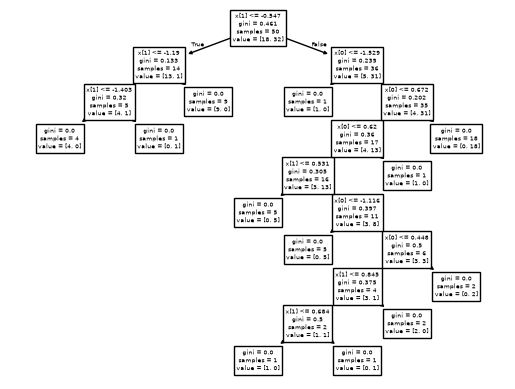

In [37]:
plot_tree(clf2)

[Text(0.5, 0.9444444444444444, 'x[0] <= -0.118\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.3333333333333333, 0.8333333333333334, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.41666666666666663, 0.8888888888888888, 'True  '),
 Text(0.6666666666666666, 0.8333333333333334, 'x[1] <= 0.643\ngini = 0.264\nsamples = 32\nvalue = [5, 27]'),
 Text(0.5833333333333333, 0.8888888888888888, '  False'),
 Text(0.5, 0.7222222222222222, 'x[0] <= 1.106\ngini = 0.459\nsamples = 14\nvalue = [5, 9]'),
 Text(0.3333333333333333, 0.6111111111111112, 'x[1] <= -0.828\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5, 0.5, 'x[0] <= 0.672\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.3333333333333333, 0.3888888888888889, 'x[1] <= -0.409\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.16666666666666666, 0.2777777777777778, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5, 0.2777777777777778, 'x[0] 

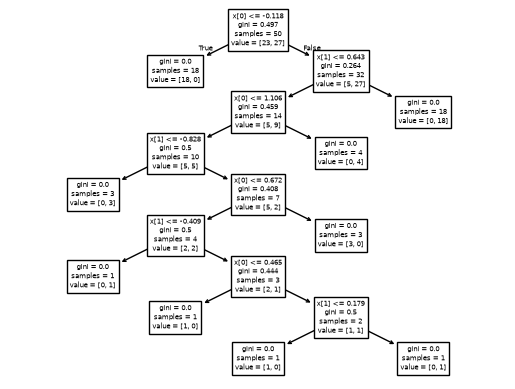

In [38]:
plot_tree(clf3)

In [39]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\mohdr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [40]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\mohdr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [41]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

C:\Users\mohdr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])